# Unit 2, Day 7: Exploratory Data Analysis (EDA) Practice

**Date:** Monday, December 15, 2025

**Instructor:** Abishek Ganesh

---

## Today's Goals
- Follow the data science process (Steps 1-4) to explore a dataset
- Create visualizations that tell the data's story
- Practice writing insight statements

---

# PART 1: Instructor-Led Walkthrough
## Dataset: Medical Insurance Costs

**Question we're investigating:** *What factors drive medical insurance costs?*

## 1.1 Setup & Data Loading

Let's start by importing our libraries and loading the data.

In [21]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for nicer plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [23]:
# Load the medical cost dataset
df = pd.read_csv('medical_cost.csv')

# First look at the data
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 1338 rows, 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1.2 Step 1 - Problem Definition

Before we dive into the data, let's clearly define what we're trying to understand:

### Our Question:
**"What factors influence how much someone pays for medical insurance?"**

### Why This Matters:
- Insurance companies need to set fair premiums
- Individuals want to understand what drives their costs
- Healthcare policy makers need data to make decisions

### What We'll Explore:
- Do smokers pay more than non-smokers?
- How does age affect insurance costs?
- Does BMI (body mass index) impact charges?
- Are there regional differences?

## 1.3 Step 2 - Initial Data Exploration

Let's understand what data we have to work with.

In [24]:
# Get info about data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Summary statistics for numerical columns
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### What do we notice from `.describe()`?

- **Age:** Ranges from 18 to 64 (working adults)
- **BMI:** Average is ~30 (considered overweight)
- **Children:** 0-5 dependents
- **Charges:** Big range! Min ~$1,100, Max ~$63,770, Mean ~$13,270
  - The mean is much higher than the median (50%) - this suggests the data is **right-skewed**

In [6]:
# Let's look at our categorical columns
print("Sex distribution:")
print(df['sex'].value_counts())
print("\nSmoker distribution:")
print(df['smoker'].value_counts())
print("\nRegion distribution:")
print(df['region'].value_counts())

Sex distribution:
sex
male      676
female    662
Name: count, dtype: int64

Smoker distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64

Region distribution:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## 1.4 Step 3 - Data Cleaning

Before we visualize, we need to check for issues.

In [25]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [26]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 1


**We found an issue!** This dataset has 1 duplicate row. Let's remove it before continuing.

In real-world scenarios, you'll often find data quality issues like this. The student practice dataset also has missing values to handle.

In [27]:
# Remove duplicate rows
print(f"Shape before: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after: {df.shape}")
print("✓ Duplicate row removed!")

Shape before: (1338, 7)
Shape after: (1337, 7)
✓ Duplicate row removed!


## 1.5 Step 4 - Visualizations & Storytelling

Now the fun part! Let's create visualizations to understand our data.

### Visualization 1: Distribution of Charges (Histogram)

**Question:** How are insurance charges distributed?

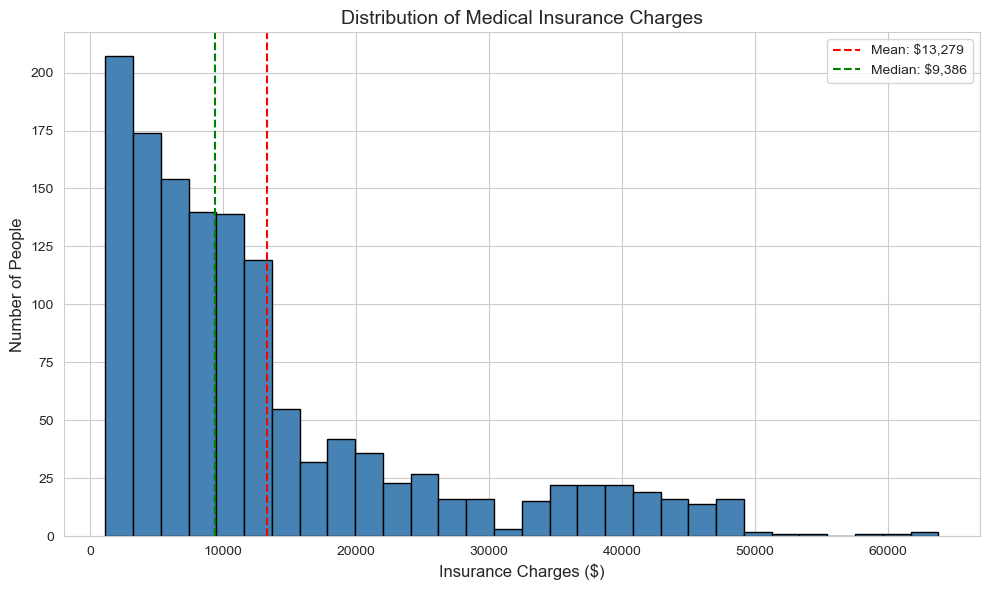

In [32]:
# Histogram of charges
plt.figure(figsize=(10, 6))
plt.hist(df['charges'], bins=30, edgecolor='black', color='steelblue')
plt.xlabel('Insurance Charges ($)', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.title('Distribution of Medical Insurance Charges', fontsize=14)

# Add a vertical line for the mean
plt.axvline(df['charges'].mean(), color='red', linestyle='--', label=f'Mean: ${df["charges"].mean():,.0f}')
plt.axvline(df['charges'].median(), color='green', linestyle='--', label=f'Median: ${df["charges"].median():,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

### Insight #1:
**Finding:** The distribution is right-skewed - most people pay $5,000-$15,000, but some pay over $50,000.

**So What?:** There's a group of high-cost individuals. Understanding WHO they are could be valuable.

### Visualization 2: Smoker vs Non-Smoker Costs (Bar Chart)

**Question:** Do smokers pay more for insurance?

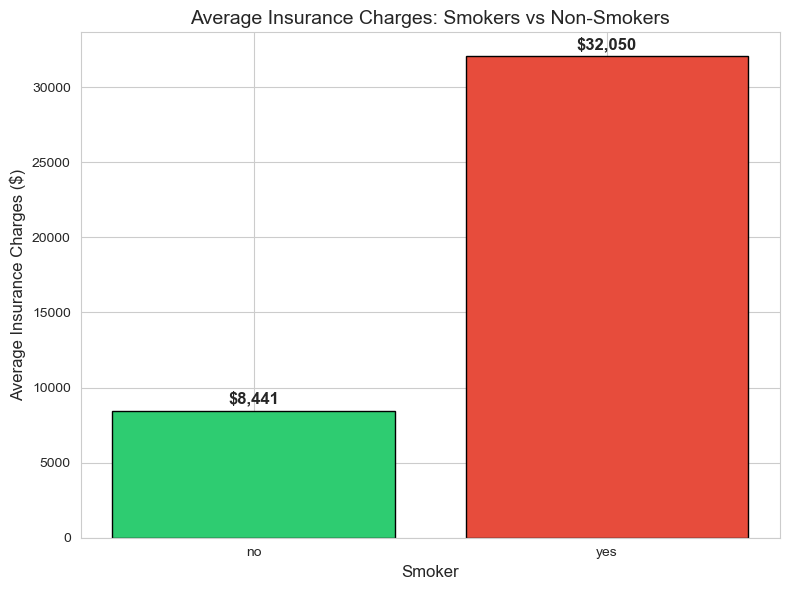

Smokers pay $23,610 MORE on average (280% higher!)


In [33]:
# Bar chart comparing smoker vs non-smoker
plt.figure(figsize=(8, 6))
smoker_avg = df.groupby('smoker')['charges'].mean()

colors = ['#2ecc71', '#e74c3c']  # Green for no, red for yes
bars = plt.bar(smoker_avg.index, smoker_avg.values, color=colors, edgecolor='black')

# Add value labels on bars
for bar, val in zip(bars, smoker_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'${val:,.0f}', ha='center', fontsize=12, fontweight='bold')

plt.xlabel('Smoker', fontsize=12)
plt.ylabel('Average Insurance Charges ($)', fontsize=12)
plt.title('Average Insurance Charges: Smokers vs Non-Smokers', fontsize=14)
plt.tight_layout()
plt.show()

# Calculate the difference
diff = smoker_avg['yes'] - smoker_avg['no']
pct_diff = (diff / smoker_avg['no']) * 100
print(f"Smokers pay ${diff:,.0f} MORE on average ({pct_diff:.0f}% higher!)")

### Insight #2:
**Finding:** Smokers pay approximately 4x MORE for insurance than non-smokers (~$32,000 vs ~$8,400).

**So What?:** Smoking is the single biggest factor affecting insurance costs. This is critical for both insurers (risk assessment) and individuals (financial motivation to quit).

### Visualization 3: Age vs Charges (Scatter Plot)

**Question:** How does age affect insurance costs? And does smoking change this relationship?

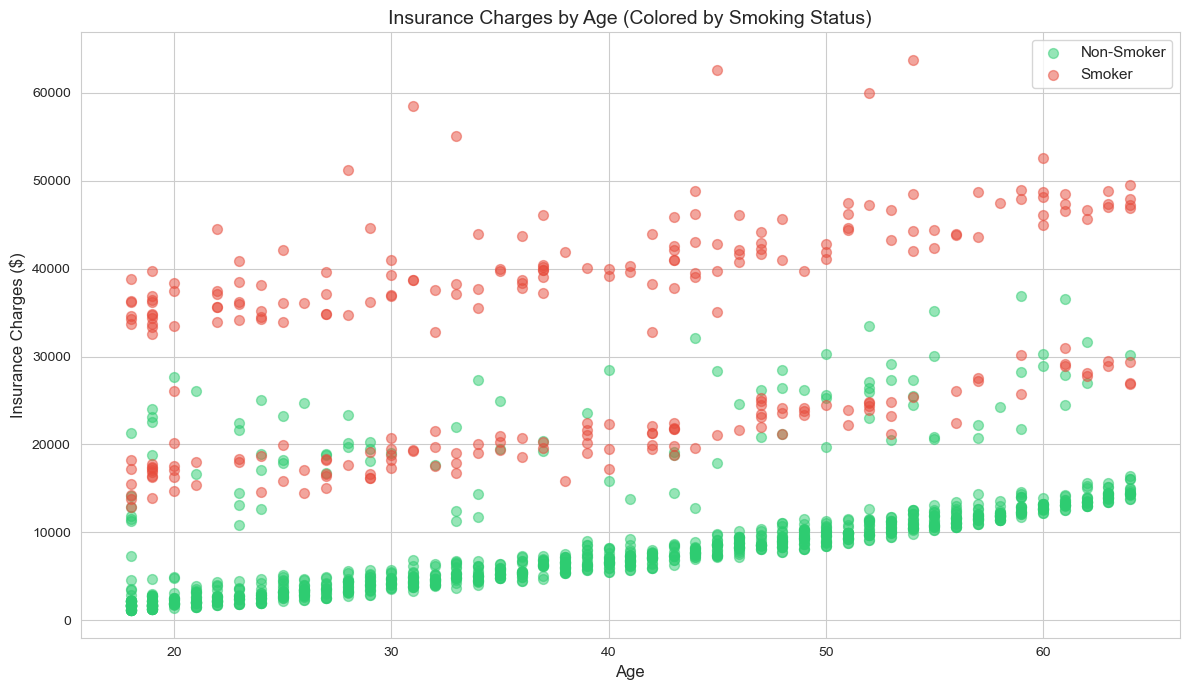

In [12]:
# Scatter plot: Age vs Charges, colored by smoker status
plt.figure(figsize=(12, 7))

# Plot non-smokers
non_smokers = df[df['smoker'] == 'no']
plt.scatter(non_smokers['age'], non_smokers['charges'], 
            alpha=0.5, c='#2ecc71', label='Non-Smoker', s=50)

# Plot smokers
smokers = df[df['smoker'] == 'yes']
plt.scatter(smokers['age'], smokers['charges'], 
            alpha=0.5, c='#e74c3c', label='Smoker', s=50)

plt.xlabel('Age', fontsize=12)
plt.ylabel('Insurance Charges ($)', fontsize=12)
plt.title('Insurance Charges by Age (Colored by Smoking Status)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Insight #3:
**Finding:** We can see THREE distinct "bands" of data:
1. **Bottom band (green):** Non-smokers - costs increase gradually with age
2. **Middle band (mixed):** Appears to be a transition zone
3. **Top band (red):** Smokers - significantly higher costs at all ages

**So What?:** Age and smoking status together create predictable cost patterns. A 25-year-old smoker pays more than a 60-year-old non-smoker!

### Visualization 4: BMI vs Charges (with Smoking)

**Question:** Does BMI affect insurance costs? What about combined with smoking?

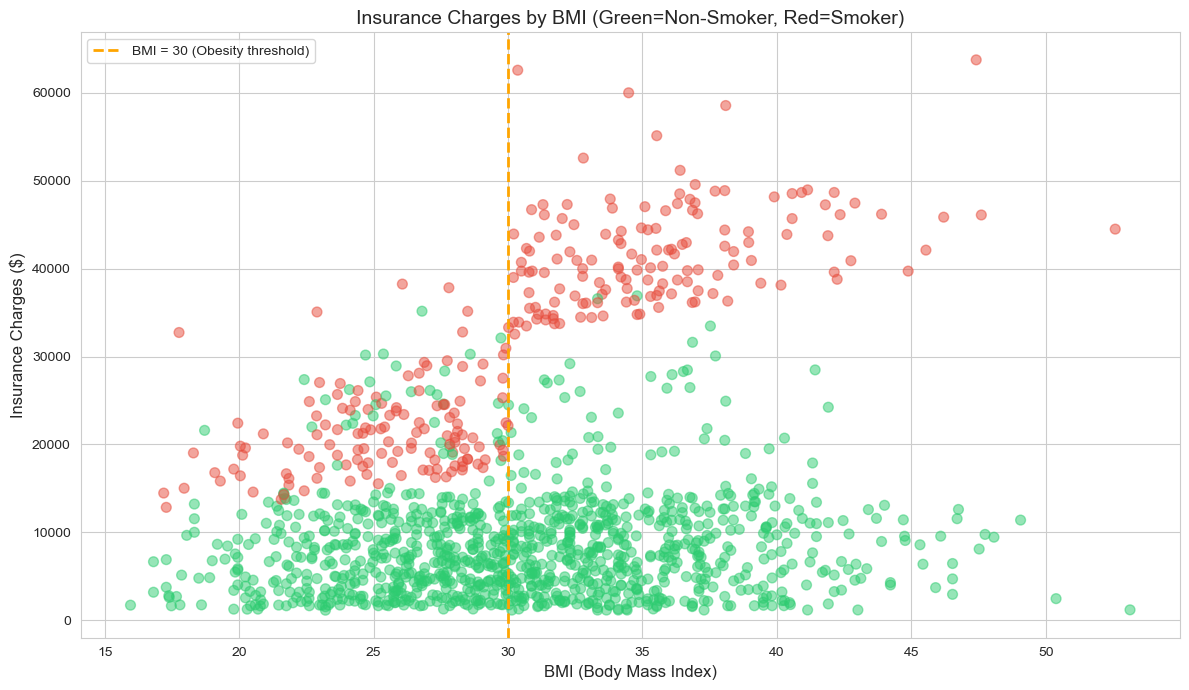

In [35]:
# Scatter plot: BMI vs Charges, colored by smoker status
plt.figure(figsize=(12, 7))

# Create a color mapping
colors = df['smoker'].map({'no': '#2ecc71', 'yes': '#e74c3c'})

plt.scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, s=50)

# Add a vertical line at BMI = 30 (obesity threshold)
plt.axvline(x=30, color='orange', linestyle='--', linewidth=2, label='BMI = 30 (Obesity threshold)')

plt.xlabel('BMI (Body Mass Index)', fontsize=12)
plt.ylabel('Insurance Charges ($)', fontsize=12)
plt.title('Insurance Charges by BMI (Green=Non-Smoker, Red=Smoker)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

### Insight #4:
**Finding:** For smokers with BMI > 30, charges skyrocket. Non-smokers show little BMI impact on costs.

**So What?:** There's an interaction effect - being a smoker AND having high BMI is particularly expensive. The combination is worse than the sum of individual effects.

### Visualization 5: Charges by Region (Box Plot)

**Question:** Are there regional differences in insurance costs?

<Figure size 1000x600 with 0 Axes>

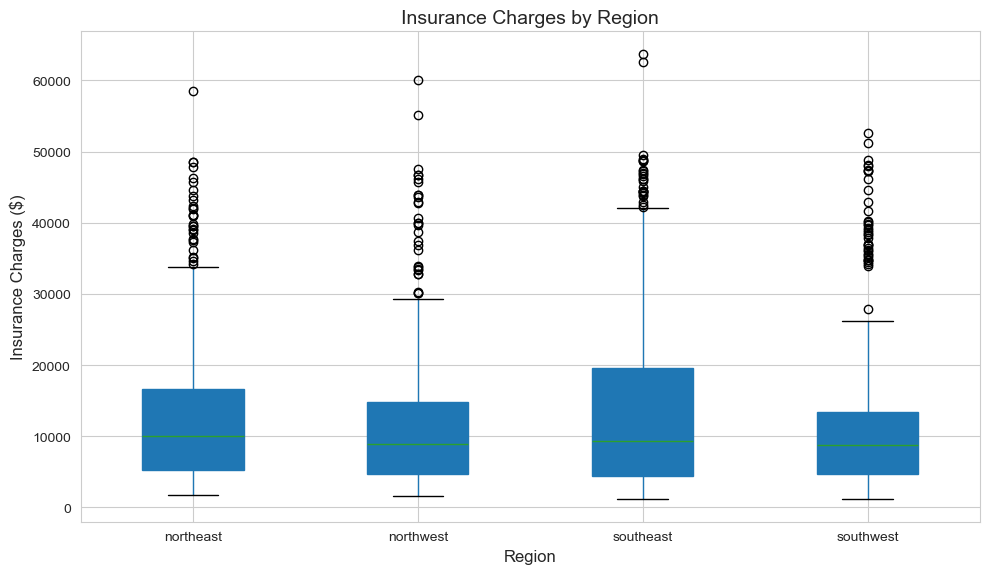


Average charges by region:
region
southeast    14735.411438
northeast    13406.384516
northwest    12450.840844
southwest    12346.937377
Name: charges, dtype: float64


In [36]:
# Box plot by region
plt.figure(figsize=(10, 6))
df.boxplot(column='charges', by='region', patch_artist=True)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Insurance Charges ($)', fontsize=12)
plt.title('Insurance Charges by Region', fontsize=14)
plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

# Show mean by region
print("\nAverage charges by region:")
print(df.groupby('region')['charges'].mean().sort_values(ascending=False))

### Insight #5:
**Finding:** Regional differences exist but are relatively small compared to smoking. Southeast has slightly higher average costs.

**So What?:** Region matters less than individual health factors. Focus on smoking and BMI for cost reduction strategies.

### Visualization 6: Correlation Heatmap

**Question:** Which numerical variables are most correlated with insurance charges?

A correlation heatmap shows the relationship strength between ALL numerical variables at once!

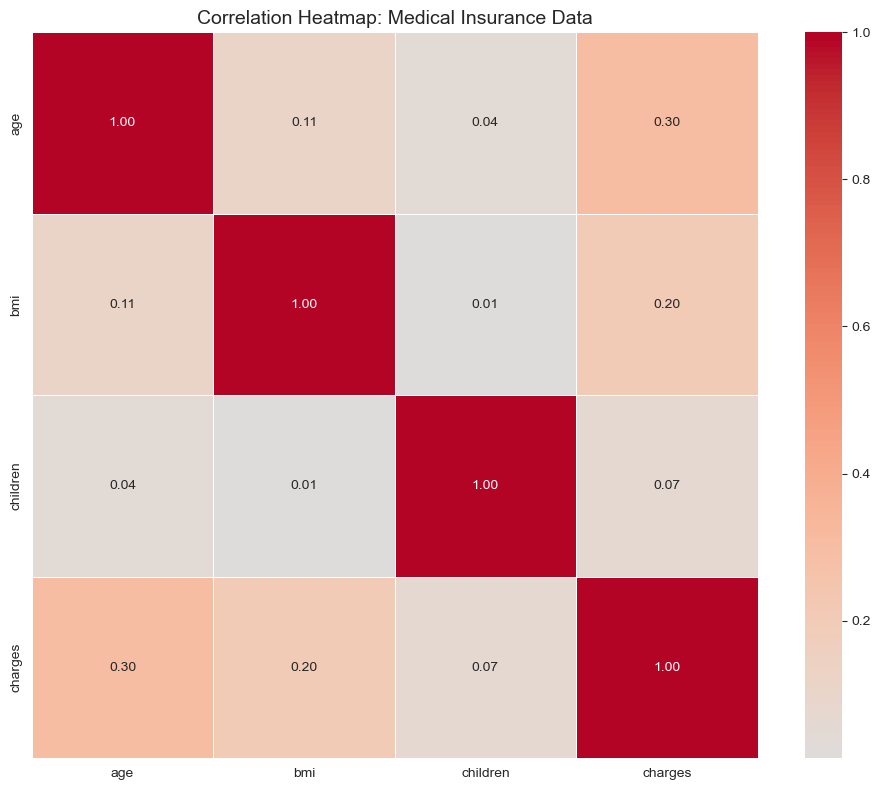


Correlations with 'charges':
charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64


In [37]:
# Correlation Heatmap - shows relationships between ALL numeric variables
plt.figure(figsize=(10, 8))

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Create the heatmap
sns.heatmap(numeric_df.corr(), 
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Red = positive, Blue = negative
            center=0,             # Center the colormap at 0
            fmt='.2f',            # 2 decimal places
            square=True,          # Make cells square
            linewidths=0.5)       # Add grid lines

plt.title('Correlation Heatmap: Medical Insurance Data', fontsize=14)
plt.tight_layout()
plt.show()

# Print the correlations with charges specifically
print("\nCorrelations with 'charges':")
print(numeric_df.corr()['charges'].sort_values(ascending=False))

### Insight #6:
**Finding:** Age has the strongest correlation with charges (r=0.30), followed by BMI (r=0.20). Number of children has almost no correlation (r=0.07).

**So What?:** The heatmap gives us a quick overview of ALL relationships at once. Notice that these correlations are relatively weak - that's because smoking (a categorical variable) is the real driver, and it's not shown in this numeric-only heatmap! This reminds us that correlation heatmaps only show LINEAR relationships between NUMERIC variables.

## 1.6 Summary: Our EDA Story

### Key Findings from Medical Insurance Cost Analysis:

1. **Smoking is the #1 cost driver** - Smokers pay ~4x more than non-smokers

2. **Age increases costs** - but the effect is much smaller than smoking

3. **BMI + Smoking = Danger Zone** - High BMI only significantly impacts costs for smokers

4. **Region has minimal impact** - Location matters less than personal health choices

### The Story:
> *"If you want to minimize your insurance costs, the single most impactful decision is not smoking. For smokers, maintaining a healthy BMI becomes critical. Age and location matter, but much less than these lifestyle factors."*

---

---

# PART 2: Collaborative EDA Practice (Breakout Rooms)

## Dataset: Stroke Prediction

**Your Question:** *What factors are associated with stroke risk?*

---

## 🎯 How This Works: The Jigsaw Method

Instead of everyone doing the same work silently, you'll **divide and conquer** - then **teach each other** what you found!

### Step 1: Assign Roles (Do this NOW!)

| Role | Person's Name | Responsibility |
|------|---------------|----------------|
| **Person A** | _____________ | Age Distribution Histogram |
| **Person B** | _____________ | Smoking Status Bar Chart |
| **Person C** | _____________ | Age vs Glucose Scatter Plot |

### Step 2: Work Flow

| Phase | What | Time |
|-------|------|------|
| **Phase 1** | TOGETHER: Load data, explore, clean | ~5-10 min |
| **Phase 2** | INDIVIDUAL: Each person creates their assigned visualization | ~10-20 min |
| **Phase 3** | TEACH BACK: Share your visualization & insight with the group | ~5-10 min |
| **Phase 4** | TOGETHER: Group analysis + write insights | ~5-10 min |

---

**Dataset columns:**
- `id`: Unique identifier
- `gender`: Male, Female, Other
- `age`: Age of the patient
- `hypertension`: 0 = No, 1 = Yes
- `heart_disease`: 0 = No, 1 = Yes
- `ever_married`: Yes or No
- `work_type`: Type of employment
- `Residence_type`: Urban or Rural
- `avg_glucose_level`: Average glucose level in blood
- `bmi`: Body Mass Index
- `smoking_status`: Smoking history
- `stroke`: 0 = No stroke, 1 = Had stroke (TARGET)

---

---
# 📍 PHASE 1: TOGETHER - Data Foundation
---

## 2.1 Setup - Load the Data

**Everyone does this together!** One person shares their screen (the "Driver"), others help (the "Navigators").

In [44]:
# Load the stroke prediction dataset
stroke_df = pd.read_csv('stroke_prediction.csv')

# YOUR CODE: Check the shape and first few rows
stroke_df.shape


(5110, 12)

## 2.2 Initial Exploration

**Task:** Use `.info()` and `.describe()` to understand the data

**Driver:** Run these cells while Navigators watch and help interpret!

In [45]:
# YOUR CODE: Get info about data types
stroke_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [46]:
# YOUR CODE: Get summary statistics
stroke_df.describe()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### 🛑 STOP & DISCUSS (2 minutes)

**Before moving on, discuss these questions as a group:**

1. What's the age range in this dataset? How does it compare to the insurance dataset?
2. Look at the `stroke` column mean - what percentage of people had strokes?
3. Did you notice anything weird about the `bmi` column in `.info()`?

**Write your group's observations below:**

*Your observations:*

## 2.3 Data Cleaning (Still TOGETHER!)

**Task:** Check for missing values. This dataset has some!

**Discuss as a group:** How should we handle missing values? Drop them? Fill them?

In [47]:
# YOUR CODE: Check for missing values
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


**Hint:** The `bmi` column has "N/A" as text, not as NaN. You may need to handle this!

In [51]:
# Check how many 'N/A' values are in bmi
print(f"Rows with 'N/A' in bmi: {(stroke_df['bmi'] == 'N/A').sum()}")

# YOUR CODE: Decide what to do with these missing values
# Option 1: Drop rows with missing bmi
# Option 2: Fill with median (after converting to numeric)
stroke_df.isnull().sum()

# Drop missing BMI values
# stroke_df =stroke_df.dropna(subset=["bmi"])
stroke_df.info()



Rows with 'N/A' in bmi: 0
<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4909 non-null   int64  
 1   gender             4909 non-null   object 
 2   age                4909 non-null   float64
 3   hypertension       4909 non-null   int64  
 4   heart_disease      4909 non-null   int64  
 5   ever_married       4909 non-null   object 
 6   work_type          4909 non-null   object 
 7   Residence_type     4909 non-null   object 
 8   avg_glucose_level  4909 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     4909 non-null   object 
 11  stroke             4909 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 498.6+ KB


In [54]:
# non_smokers = df[df['smoker'] == 'no']
stroke_df.head()

# Show all categories 
stroke_df['smoking_status'].value_counts()



stroke_df["is_smoker"] = stroke_df['smoking_status'].apply(lambda x: 1 if x == 'smokes' else 0)

In [55]:
stroke_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,is_smoker
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,0
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,0
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,0


---
# 📍 PHASE 2: DIVIDE & CONQUER - Individual Visualizations
---

## 2.4 Visualizations

**Now split up!** Each person works on their assigned visualization. You have ~10 minutes.

- **Person A:** Scroll to "Visualization 1" (Age Distribution)
- **Person B:** Scroll to "Visualization 2" (Smoking Status)
- **Person C:** Scroll to "Visualization 3" (Age vs Glucose)

> **Tip:** You can all work in your own notebooks simultaneously!

---

### 👤 PERSON A: Age Distribution (Histogram)
**Your Question:** What does the age distribution look like? Are strokes more common in certain age groups?

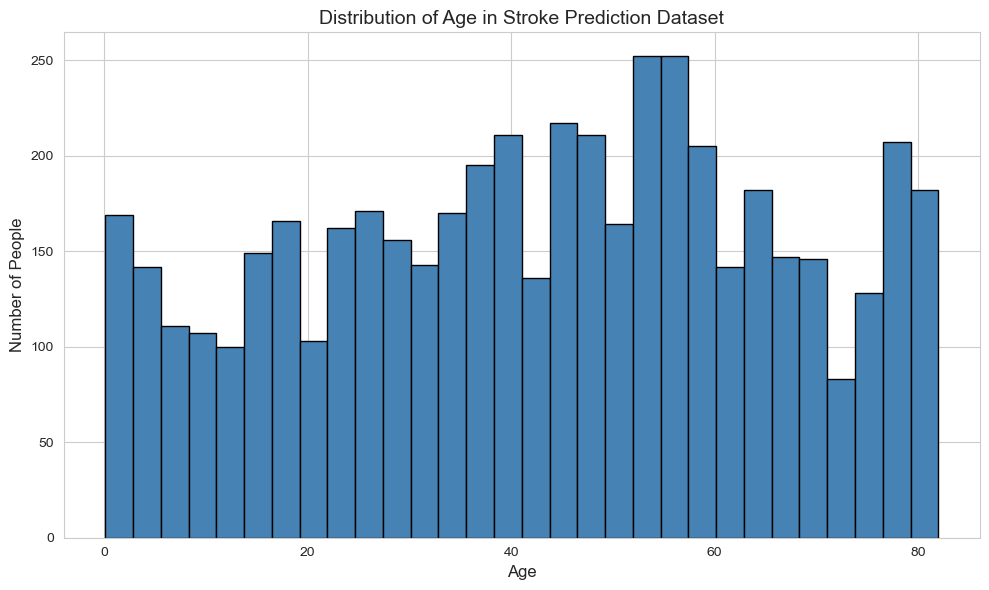

In [61]:
# YOUR CODE: Create a histogram of age
plt.figure(figsize=(10, 6))
plt.hist(stroke_df['age'], bins=30, edgecolor='black', color='steelblue')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.title('Distribution of Age in Stroke Prediction Dataset', fontsize=14)
plt.tight_layout()
plt.show()

---

### 👤 PERSON B: Stroke Rate by Smoking Status (Bar Chart)
**Your Question:** Does smoking status affect stroke risk? Which group has the highest stroke rate?

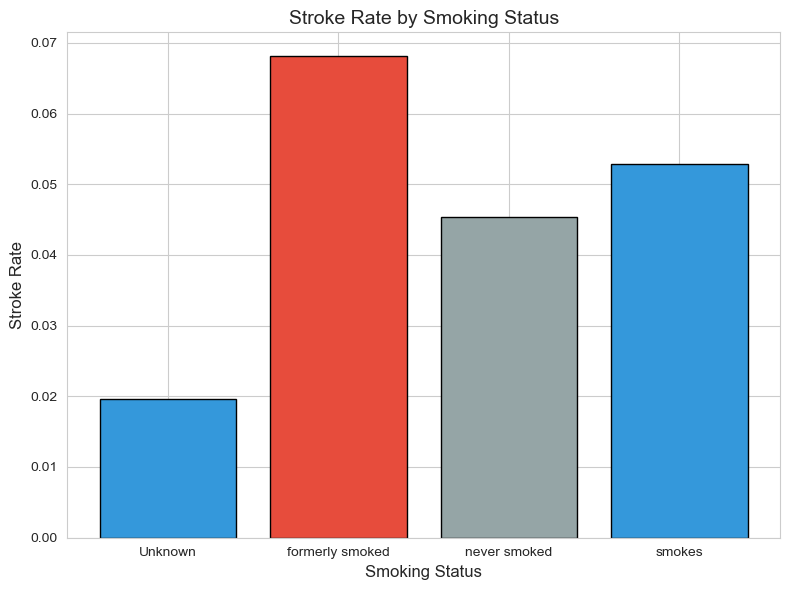

In [60]:
# YOUR CODE: Bar chart of stroke rate by smoking status
# Hint: Use groupby on 'smoking_status' and calculate mean of 'stroke'

plt.figure(figsize=(8, 6))
smoker_stroke_rate = stroke_df.groupby('smoking_status')['stroke'].mean()
# --- IGNORE ---
# - --- IGNORE ---
plt.bar(smoker_stroke_rate.index, smoker_stroke_rate.values, color=['#3498db', '#e74c3c', '#95a5a6'], edgecolor='black')
# - --- IGNORE ---
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Stroke Rate', fontsize=12)
plt.title('Stroke Rate by Smoking Status', fontsize=14)
plt.tight_layout()
plt.show()

---

### 👤 PERSON C: Age vs Glucose Level (Scatter Plot)
**Your Question:** Is there a relationship between age and glucose levels? Where do stroke patients appear on this plot?

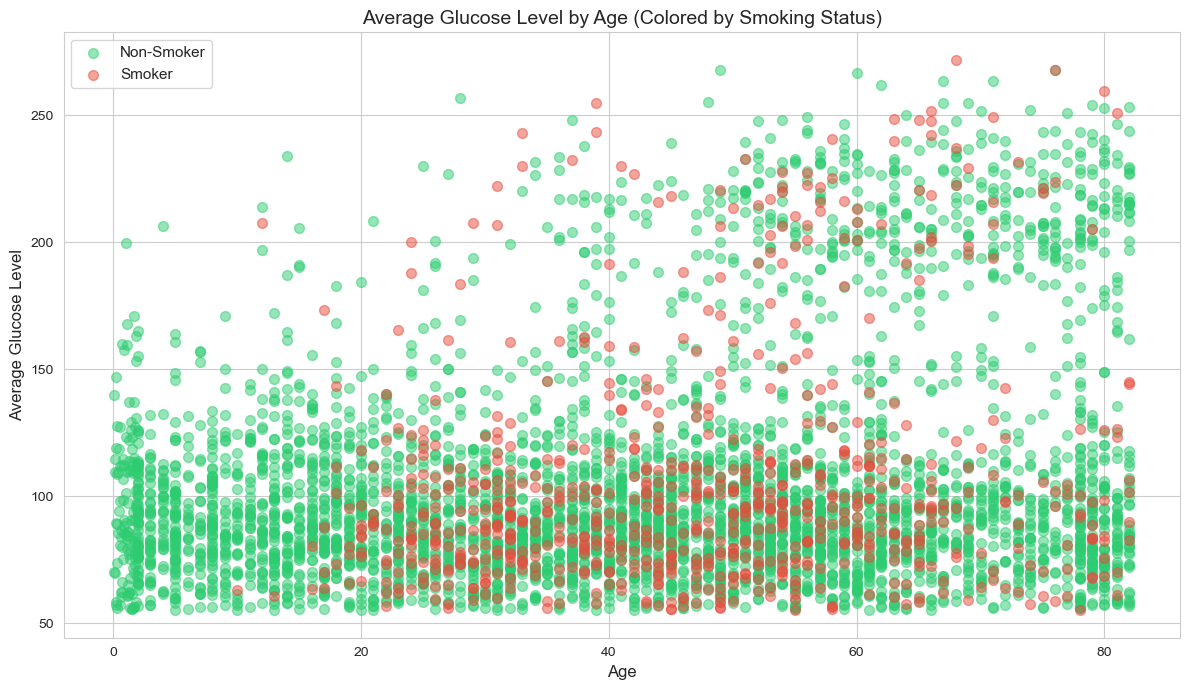

In [62]:
# YOUR CODE: Scatter plot of age vs avg_glucose_level
# Color by stroke status (0 or 1)

# Scatter plot: Age vs Charges, colored by smoker status
plt.figure(figsize=(12, 7))

# Plot non-smokers
df_non_smokers = stroke_df[stroke_df['is_smoker'] == 0]
plt.scatter(df_non_smokers['age'], df_non_smokers['avg_glucose_level'], 
            alpha=0.5, c='#2ecc71', label='Non-Smoker', s=50)

# Plot smokers
# smokers = df[df['smoker'] == 'yes']
df_smokers = stroke_df[stroke_df['is_smoker'] == 1]
plt.scatter(df_smokers['age'], df_smokers['avg_glucose_level'], 
            alpha=0.5, c='#e74c3c', label='Smoker', s=50)

plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Glucose Level', fontsize=12)
plt.title('Average Glucose Level by Age (Colored by Smoking Status)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
# 📍 PHASE 3: TEACH BACK - Share Your Findings!
---

## 2.5 Share What You Learned (10 minutes)

**Come back together as a group!** Each person shares their visualization.

### How to Teach Back:
1. **Share your screen** showing your visualization
2. **Explain what you see** (describe the chart)
3. **Share your insight** using the Finding → So What format

### 🎤 Person A shares Age Distribution:
**My Finding:**

**So What?:**

---

### 🎤 Person B shares Smoking Status:
**My Finding:**

**So What?:**

---

### 🎤 Person C shares Age vs Glucose:
**My Finding:**

**So What?:**

---

---
# 📍 PHASE 4: TOGETHER - Group Analysis
---

## 2.6 Group Visualizations

**Back to working together!** Driver shares screen, everyone contributes ideas.

### 🛑 STOP & PREDICT (Before running code!)

**Discuss as a group:** What do you THINK you'll see?

1. Do you think people with hypertension have higher stroke rates? By how much?
2. What about heart disease?
3. Which numeric variables do you predict will be most correlated with stroke?

*Write your group's predictions:*

---

### Visualization 4: Hypertension & Heart Disease Impact

In [ ]:
# GROUP CODE: Stroke rates by hypertension and heart disease
# Work together to create visualizations for both!

# Hypertension analysis
print("Stroke rate by hypertension status:")
print(stroke_df.groupby('hypertension')['stroke'].mean() * 100)

# YOUR CODE: Create a bar chart comparing stroke rates
# for people WITH vs WITHOUT hypertension



### Visualization 5: Correlation Heatmap

**Task:** Create a correlation heatmap to see ALL numeric relationships at once.

In [ ]:
# GROUP CODE: Create a correlation heatmap
# Hint: Use sns.heatmap() with stroke_df.select_dtypes(include=['number']).corr()



### 🛑 STOP & REFLECT: Were Your Predictions Correct?

**Discuss as a group:**
1. Did hypertension increase stroke risk as much as you expected?
2. Any surprises in the correlation heatmap?
3. What's the MOST important factor you've discovered?

*Write your reflections:*

---
# 📍 PHASE 5: GROUP SUMMARY - Write Your Story Together!
---

## 2.7 Your Group's Key Insights

**Work together to write 3 insights** - one from each person's visualization!

---

### Insight #1 (From Person A's Age Analysis):
**Finding:** 

**So What?:** 

---

### Insight #2 (From Person B's Smoking Analysis):
**Finding:** 

**So What?:** 

---

### Insight #3 (From Person C's Glucose Analysis):
**Finding:** 

**So What?:** 

---

## 2.8 Your Group's Story

**Write a 2-3 sentence summary of what you learned about stroke risk factors:**

> *"Based on our analysis, we found that..."*

---

## 2.6 Challenge Questions (Optional)

If you finish early, try to answer these:

1. **Which factor seems MOST associated with stroke risk?** (age? hypertension? smoking? glucose?)

2. **Are there any SURPRISING findings?** Something that goes against what you'd expect?

3. **What additional data would you want to collect** to better predict stroke risk?

In [ ]:
# CHALLENGE: Your exploratory code here



---

# Great work today!

You've practiced:
- Loading and exploring data
- Checking for missing values
- Creating meaningful visualizations
- Writing insight statements that tell a story

**Remember:** EDA is about understanding your data BEFORE you build models. The visualizations and insights you create guide your modeling decisions!

---